In [ ]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

In [ ]:
import pandas as pd

# Weather dataset (Play Tennis)
data = {
    'Outlook': [
        'Sunny','Sunny','Overcast','Rain','Rain','Rain','Overcast',
        'Sunny','Sunny','Rain','Sunny','Overcast','Overcast','Rain'
    ],

    'Temperature': [
        'Hot','Hot','Hot','Mild','Cool','Cool','Cool',
        'Mild','Cool','Mild','Mild','Mild','Hot','Mild'
    ],

    'Humidity': [
        'High','High','High','High','Normal','Normal','Normal',
        'High','Normal','Normal','Normal','High','Normal','High'
    ],

    'Wind': [
        'Weak','Strong','Weak','Weak','Weak','Strong','Strong',
        'Weak','Weak','Weak','Strong','Strong','Weak','Strong'
    ],

    'PlayTennis': [
        'No','No','Yes','Yes','Yes','No','Yes',
        'No','Yes','Yes','Yes','Yes','Yes','No'
    ]
}

# Convert to dataframe
df = pd.DataFrame(data)

print(df)

     Outlook Temperature Humidity    Wind PlayTennis
0      Sunny         Hot     High    Weak         No
1      Sunny         Hot     High  Strong         No
2   Overcast         Hot     High    Weak        Yes
3       Rain        Mild     High    Weak        Yes
4       Rain        Cool   Normal    Weak        Yes
5       Rain        Cool   Normal  Strong         No
6   Overcast        Cool   Normal  Strong        Yes
7      Sunny        Mild     High    Weak         No
8      Sunny        Cool   Normal    Weak        Yes
9       Rain        Mild   Normal    Weak        Yes
10     Sunny        Mild   Normal  Strong        Yes
11  Overcast        Mild     High  Strong        Yes
12  Overcast         Hot   Normal    Weak        Yes
13      Rain        Mild     High  Strong         No


In [ ]:
#Prepare Data
X = df.drop('PlayTennis', axis=1)
y = df['PlayTennis']

# Convert categorical values into numbers
X = pd.get_dummies(X)

X

,Outlook_Overcast,Outlook_Rain,Outlook_Sunny,Temperature_Cool,Temperature_Hot,Temperature_Mild,Humidity_High,Humidity_Normal,Wind_Strong,Wind_Weak
0,False,False,True,False,True,False,True,False,False,True
1,False,False,True,False,True,False,True,False,True,False
2,True,False,False,False,True,False,True,False,False,True
3,False,True,False,False,False,True,True,False,False,True
4,False,True,False,True,False,False,False,True,False,True
5,False,True,False,True,False,False,False,True,True,False
6,True,False,False,True,False,False,False,True,True,False
7,False,False,True,False,False,True,True,False,False,True
8,False,False,True,True,False,False,False,True,False,True
9,False,True,False,False,False,True,False,True,False,True


In [ ]:
#ID3 Decision Tree (Entropy)
id3_model = DecisionTreeClassifier(criterion='entropy')

id3_model.fit(X, y)

print("ID3 Model Trained Successfully")

ID3 Model Trained Successfully


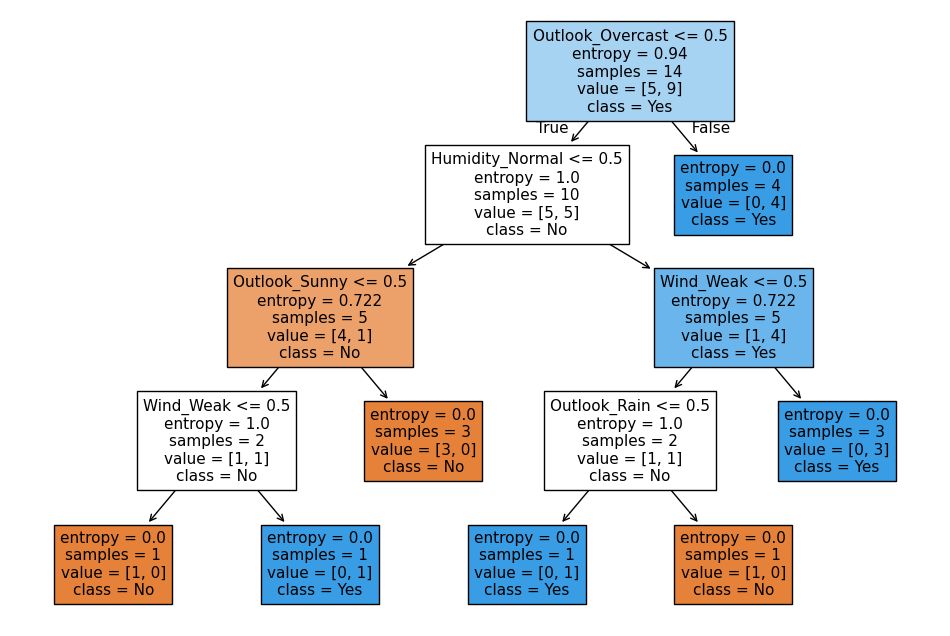

In [ ]:
#Visualize ID3 Tree

plt.figure(figsize=(12,8))
plot_tree(id3_model,
          feature_names=X.columns,
          class_names=['No','Yes'],
          filled=True)

plt.show()

In [ ]:
#CART Decision Tree (Gini)
cart_model = DecisionTreeClassifier(criterion='gini')

cart_model.fit(X, y)

print("CART Model Trained Successfully")

CART Model Trained Successfully


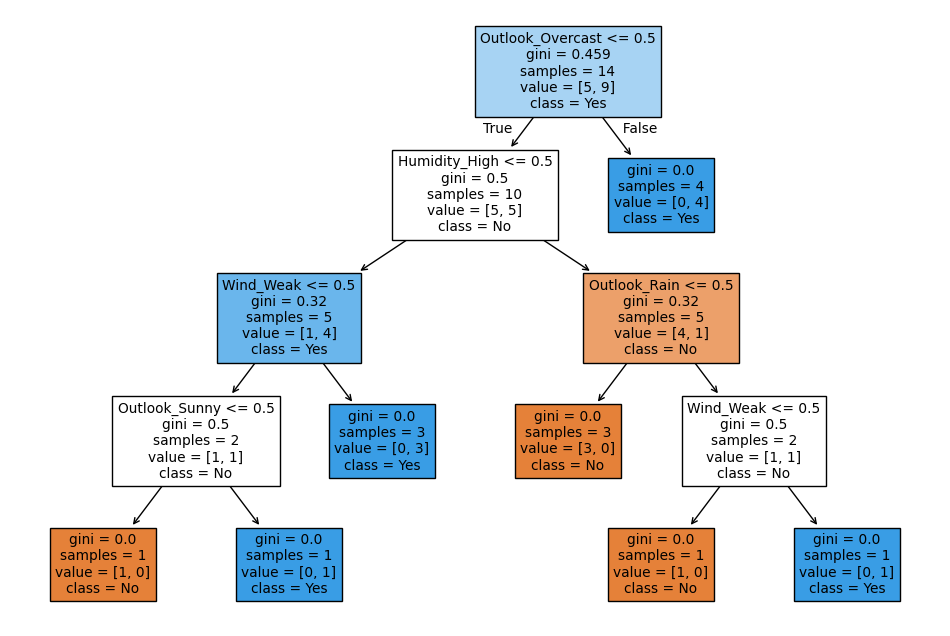

In [ ]:
#Visualize CART Tree
plt.figure(figsize=(12,8))
plot_tree(cart_model,
          feature_names=X.columns,
          class_names=['No','Yes'],
          filled=True)

plt.show()

In [ ]:
sample1 = pd.DataFrame({
    'Outlook': ['Overcast'],
    'Temperature': ['Hot'],
    'Humidity': ['High'],
    'Wind': ['Weak']
})

sample1 = pd.get_dummies(sample1)
sample1 = sample1.reindex(columns=X.columns, fill_value=0)

print("ID3 Prediction:", id3_model.predict(sample1))
print("CART Prediction:", cart_model.predict(sample1))

ID3 Prediction: ['Yes']
CART Prediction: ['Yes']


In [ ]:
sample2 = pd.DataFrame({
    'Outlook': ['Rain'],
    'Temperature': ['Cool'],
    'Humidity': ['Normal'],
    'Wind': ['Strong']
})

sample2 = pd.get_dummies(sample2)
sample2 = sample2.reindex(columns=X.columns, fill_value=0)

print("ID3 Prediction:", id3_model.predict(sample2))
print("CART Prediction:", cart_model.predict(sample2))

ID3 Prediction: ['No']
CART Prediction: ['No']
